# EconIQ: Food Price Forecasting

The goal of this project is to predict the food price for the following month using historical food prices, economic indicators, weather information, and commodity type.

We will compare:
- Naive forecasting
- Random Forest
- XGBoost

The dataset contains food-price observations for different commodities in Kenya.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

import joblib
import json

pd.set_option("display.max_columns", None)

In [ ]:
df = pd.read_csv(
    "../data/processed/food_price_prediction.csv",
    parse_dates=["date", "target_date"]
)

df.head()

In [ ]:
df.tail()

In [ ]:
print(df.shape)
print(df.info())

In [ ]:
df.describe()

In [ ]:
df.isnull().sum().sort_values(ascending=False)

In [ ]:
missing = pd.DataFrame({
    "missing": df.isnull().sum(),
    "percentage": df.isnull().mean() * 100
})

missing[missing["missing"] > 0]

In [ ]:
df.duplicated().sum()

In [ ]:
df.duplicated(subset=["date", "commodity"]).sum()

In [ ]:
print("Start date:", df["date"].min().date())
print("End date:", df["date"].max().date())
print("Number of months:", df["date"].nunique())

In [ ]:
df["commodity"].nunique()

In [ ]:
df["commodity"].unique()

## EDA

In [ ]:
# Food Price Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    df["food_price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Food Prices")
plt.xlabel("Food Price")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df["food_price"].describe()

In [ ]:
# Food Prices by Commodity

plt.figure(figsize=(14, 8))

sns.boxplot(
    data=df,
    x="food_price",
    y="commodity"
)

plt.title("Food Price Distribution by Commodity")
plt.xlabel("Food Price")
plt.ylabel("Commodity")

plt.show()

In [ ]:
#  Number of Observations per Commodity

commodity_counts = df["commodity"].value_counts()

plt.figure(figsize=(12, 8))

commodity_counts.sort_values().plot(
    kind="barh"
)

plt.title("Number of Observations per Commodity")
plt.xlabel("Number of Observations")
plt.ylabel("Commodity")

plt.show()

In [ ]:
# Food Prices Over Time

monthly_prices = (
    df.groupby("date")["food_price"]
    .mean()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_prices.index,
    monthly_prices.values
)

plt.title("Average Food Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average Food Price")

plt.show()

In [ ]:
# Seasonality

df["month"] = df["date"].dt.month

monthly_seasonality = (
    df.groupby("month")["food_price"]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o"
)

plt.title("Average Food Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Food Price")

plt.xticks(range(1, 13))

plt.show()

In [ ]:
# Monthly Food Price Changes

plt.figure(figsize=(10, 6))

sns.histplot(
    df["food_price_change_1m"].dropna(),
    bins=40,
    kde=True
)

plt.title("Distribution of Monthly Food Price Changes")
plt.xlabel("Monthly Price Change")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df["food_price_change_1m"].describe()

In [ ]:
# Current Food Price vs Next-Month Food Price

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="food_price",
    y="target_food_price_next_month",
    alpha=0.5
)

plt.title("Current Food Price vs Next-Month Food Price")
plt.xlabel("Current Food Price")
plt.ylabel("Next-Month Food Price")

plt.show()

In [ ]:
df[
    ["food_price", "target_food_price_next_month"]
].corr()

In [ ]:
#  Historical Price Features

lag_features = [
    "food_price",
    "food_price_lag_1",
    "food_price_lag_3",
    "food_price_lag_6",
    "food_price_lag_12",
    "food_price_ma_3",
    "food_price_ma_6",
    "food_price_change_1m"
]

lag_correlations = (
    df[lag_features + ["target_food_price_next_month"]]
    .corr()["target_food_price_next_month"]
    .sort_values(ascending=False)
)

lag_correlations

In [ ]:
plt.figure(figsize=(10, 6))

lag_correlations.drop(
    "target_food_price_next_month"
).sort_values().plot(
    kind="barh"
)

plt.title("Historical Price Features vs Next-Month Price")
plt.xlabel("Correlation")

plt.show()

In [ ]:
#  Correlation Matrix

numeric_columns = df.select_dtypes(include="number").columns

correlation_matrix = df[numeric_columns].corr()

In [ ]:
plt.figure(figsize=(16, 12))

sns.heatmap(correlation_matrix, cmap="coolwarm", center=0 )

plt.title("Correlation Matrix")

plt.show()

In [ ]:
# Weather

weather_features = [
    "rainfall",
    "temperature",
    "temperature_max",
    "temperature_min",
    "humidity",
    "wind_speed"
]

df[weather_features].describe()

In [ ]:
df[weather_features].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

In [ ]:
# Inflation and Food Prices

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="inflation_12m",
    y="food_price",
    alpha=0.5
)

plt.title("Inflation vs Food Price")
plt.xlabel("12-Month Inflation")
plt.ylabel("Food Price")

plt.show()

In [ ]:
df[
    ["inflation_12m", "food_price"]
].corr()

In [ ]:
# Extreme Price Changes

threshold = df["food_price_change_1m"].abs().quantile(0.99)

extreme_prices = df[
    df["food_price_change_1m"].abs() >= threshold
]

extreme_prices[
    [
        "date",
        "commodity",
        "food_price",
        "food_price_change_1m",
        "target_food_price_next_month"
    ]
].sort_values(
    "food_price_change_1m",
    key=abs,
    ascending=False
).head(20)

In [ ]:
# Check data leakage

target = "target_food_price_next_month"

print("Target:", target)

possible_leakage = [
    "target_food_price_next_month",
    "target_date"
]

for column in possible_leakage:
    if column in df.columns:
        print(column, "is present")

In [ ]:
df[[
    "date",
    "target_date",
    "food_price",
    "food_price_lag_1",
    "food_price_lag_3",
    "food_price_lag_6",
    "food_price_lag_12",
    "food_price_ma_3",
    "food_price_ma_6",
    "target_food_price_next_month"
]].head(15)

In [ ]:
# Verifyy target date is one month after the current date

expected_target_date = df["date"] + pd.DateOffset(months=1)

date_check = df["target_date"] == expected_target_date

print("Incorrect target dates:", (~date_check).sum())

In [ ]:
print(df[["date", "target_date", "food_price", "target_food_price_next_month"]].head(10))

In [ ]:
features = [
    "commodity",
    "food_price",
    "inflation_annual_avg",
    "inflation_12m",
    "central_bank_rate",
    "rainfall",
    "temperature",
    "temperature_max",
    "temperature_min",
    "humidity",
    "wind_speed",
    "food_price_lag_1",
    "food_price_lag_3",
    "food_price_lag_6",
    "food_price_lag_12",
    "food_price_change_1m",
    "food_price_ma_3",
    "food_price_ma_6",
    "central_bank_rate_change_1m"
]

target = "target_food_price_next_month"

In [ ]:
missing_features = [column for column in features if column not in df.columns]

print("Missing features:", missing_features)
print("Number of features:", len(features))

In [ ]:
df[features + [target]].isnull().sum().sort_values(ascending=False)

In [ ]:
df[df["food_price_lag_12"].isnull()][
    ["date", "commodity", "food_price", "food_price_lag_12"]
].head(20)

In [ ]:
df.groupby("commodity")["date"].agg(["min", "max", "count"]).sort_values("min")

In [ ]:
required_lag_features = [
    "food_price_lag_1",
    "food_price_lag_3",
    "food_price_lag_6",
    "food_price_lag_12"
]

df_model = df.dropna(subset=required_lag_features).copy()

print("Original rows:", len(df))
print("Rows after removing missing lag history:", len(df_model))

In [ ]:
df_model[required_lag_features].isnull().sum()

In [ ]:
df_model[features + [target]].isnull().sum().sort_values(ascending=False)

In [ ]:
commodity_counts = (
    df_model["commodity"]
    .value_counts()
    .sort_values()
)

commodity_counts

In [ ]:
plt.figure(figsize=(10, 8))

commodity_counts.plot(kind="barh")

plt.title("Commodity observations after cleaning")
plt.xlabel("Number of observations")
plt.ylabel("Commodity")
plt.show()

In [ ]:
unique_dates = sorted(df_model["date"].unique())

print("Number of dates:", len(unique_dates))
print("First date:", unique_dates[0])
print("Last date:", unique_dates[-1])

In [ ]:
commodity_dates = df_model.groupby("commodity")["date"].agg(
    ["min", "max", "count"]
)

commodity_dates.sort_values("min")

In [ ]:
latest_start = df_model.groupby("commodity")["date"].min().max()

print("Latest commodity start date:", latest_start)

In [ ]:
# split the data into training, validation, and test sets based on time series split

train_parts = []
validation_parts = []
test_parts = []

for commodity in df_model["commodity"].unique():

    commodity_data = df_model[
        df_model["commodity"] == commodity
    ].sort_values("date").copy()

    n = len(commodity_data)

    train_end = int(n * 0.70)
    validation_end = int(n * 0.85)

    train_parts.append(
        commodity_data.iloc[:train_end]
    )

    validation_parts.append(
        commodity_data.iloc[train_end:validation_end]
    )

    test_parts.append(
        commodity_data.iloc[validation_end:]
    )

train = pd.concat(train_parts, ignore_index=True)
validation = pd.concat(validation_parts, ignore_index=True)
test = pd.concat(test_parts, ignore_index=True)

print("Training rows:", len(train))
print("Validation rows:", len(validation))
print("Test rows:", len(test))

In [ ]:
print("Training commodities:", train["commodity"].nunique())
print("Validation commodities:", validation["commodity"].nunique())
print("Test commodities:", test["commodity"].nunique())

In [ ]:
print("Training date range:")
print(train["date"].min(), "to", train["date"].max())

print("\nValidation date range:")
print(validation["date"].min(), "to", validation["date"].max())

print("\nTest date range:")
print(test["date"].min(), "to", test["date"].max())

In [ ]:
check = train.groupby("commodity")["date"].max().to_frame("train_end")

check["validation_start"] = validation.groupby(
    "commodity"
)["date"].min()

check["validation_end"] = validation.groupby(
    "commodity"
)["date"].max()

check["test_start"] = test.groupby(
    "commodity"
)["date"].min()

check

In [ ]:
X_train = train[features].copy()
y_train = train[target].copy()

X_validation = validation[features].copy()
y_validation = validation[target].copy()

X_test = test[features].copy()
y_test = test[target].copy()

In [ ]:
categorical_features = ["commodity"]

numeric_features = [
    column for column in features
    if column not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "commodity",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

In [ ]:
print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

### Naive forecasting baseline

In [102]:
naive_validation_pred = validation["food_price"].values
naive_test_pred = test["food_price"].values

naive_validation_mae = mean_absolute_error(
    y_validation,
    naive_validation_pred
)

naive_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        naive_validation_pred
    )
)

naive_validation_r2 = r2_score(
    y_validation,
    naive_validation_pred
)

naive_test_mae = mean_absolute_error(
    y_test,
    naive_test_pred
)

naive_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        naive_test_pred
    )
)

naive_test_r2 = r2_score(
    y_test,
    naive_test_pred
)

print("Naive validation MAE:", naive_validation_mae)
print("Naive validation RMSE:", naive_validation_rmse)
print("Naive validation R2:", naive_validation_r2)

print("Naive test MAE:", naive_test_mae)
print("Naive test RMSE:", naive_test_rmse)
print("Naive test R2:", naive_test_r2)

Naive validation MAE: 225.1323628691983
Naive validation RMSE: 767.1611095168103
Naive validation R2: 0.9102198609082983
Naive test MAE: 224.14588932806322
Naive test RMSE: 723.5716937464501
Naive test R2: 0.9322969318687656


In [103]:
baseline_results = pd.DataFrame({
    "Model": ["Naive"],
    "Validation MAE": [naive_validation_mae],
    "Validation RMSE": [naive_validation_rmse],
    "Validation R2": [naive_validation_r2],
    "Test MAE": [naive_test_mae],
    "Test RMSE": [naive_test_rmse],
    "Test R2": [naive_test_r2]
})

baseline_results

,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,Naive,225.132363,767.16111,0.91022,224.145889,723.571694,0.932297


In [104]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

rf_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['commodity','food_price','inflation_annual_avg',...,'food_price_ma_3', 'food_price_ma_6','central_bank_rate_change_1m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('commodity', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [105]:
rf_validation_pred = rf_pipeline.predict(X_validation)

rf_validation_mae = mean_absolute_error(y_validation, rf_validation_pred)

rf_validation_rmse = np.sqrt(mean_squared_error(y_validation, rf_validation_pred))

rf_validation_r2 = r2_score(y_validation, rf_validation_pred)

print("Random Forest validation MAE:", rf_validation_mae)
print("Random Forest validation RMSE:", rf_validation_rmse)
print("Random Forest validation R2:", rf_validation_r2)

Random Forest validation MAE: 217.62578558063944
Random Forest validation RMSE: 671.0037353548836
Random Forest validation R2: 0.9313157765638629


In [106]:
rf_test_pred = rf_pipeline.predict(
    X_test
)

rf_test_mae = mean_absolute_error(
    y_test,
    rf_test_pred
)

rf_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_test_pred
    )
)

rf_test_r2 = r2_score(
    y_test,
    rf_test_pred
)

print("Random Forest test MAE:", rf_test_mae)
print("Random Forest test RMSE:", rf_test_rmse)
print("Random Forest test R2:", rf_test_r2)

Random Forest test MAE: 254.34287510293763
Random Forest test RMSE: 721.4011792124261
Random Forest test R2: 0.9327025035329685


In [107]:
rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Validation MAE": [rf_validation_mae],
    "Validation RMSE": [rf_validation_rmse],
    "Validation R2": [rf_validation_r2],
    "Test MAE": [rf_test_mae],
    "Test RMSE": [rf_test_rmse],
    "Test R2": [rf_test_r2]
})

model_results = pd.concat(
    [baseline_results, rf_results],
    ignore_index=True
)

model_results

,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,Naive,225.132363,767.161110,0.910220,224.145889,723.571694,0.932297
1,Random Forest,217.625786,671.003735,0.931316,254.342875,721.401179,0.932703


In [108]:
xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

xgb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['commodity','food_price','inflation_annual_avg',...,'food_price_ma_3', 'food_price_ma_6','central_bank_rate_change_1m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('commodity', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [109]:
xgb_validation_pred = xgb_pipeline.predict(
    X_validation
)

xgb_validation_mae = mean_absolute_error(
    y_validation,
    xgb_validation_pred
)

xgb_validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        xgb_validation_pred
    )
)

xgb_validation_r2 = r2_score(
    y_validation,
    xgb_validation_pred
)

print("XGBoost validation MAE:", xgb_validation_mae)
print("XGBoost validation RMSE:", xgb_validation_rmse)
print("XGBoost validation R2:", xgb_validation_r2)

XGBoost validation MAE: 213.5287891801601
XGBoost validation RMSE: 576.843043844771
XGBoost validation R2: 0.9492399038112298


In [110]:
xgb_test_pred = xgb_pipeline.predict(
    X_test
)

xgb_test_mae = mean_absolute_error(
    y_test,
    xgb_test_pred
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_test_pred
    )
)

xgb_test_r2 = r2_score(
    y_test,
    xgb_test_pred
)

print("XGBoost test MAE:", xgb_test_mae)
print("XGBoost test RMSE:", xgb_test_rmse)
print("XGBoost test R2:", xgb_test_r2)

XGBoost test MAE: 273.14375696823066
XGBoost test RMSE: 795.0338109039998
XGBoost test R2: 0.9182634298665412


In [111]:
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Validation MAE": [xgb_validation_mae],
    "Validation RMSE": [xgb_validation_rmse],
    "Validation R2": [xgb_validation_r2],
    "Test MAE": [xgb_test_mae],
    "Test RMSE": [xgb_test_rmse],
    "Test R2": [xgb_test_r2]
})

model_results = pd.concat(
    [baseline_results, rf_results, xgb_results],
    ignore_index=True
)

model_results

,Model,Validation MAE,Validation RMSE,Validation R2,Test MAE,Test RMSE,Test R2
0,Naive,225.132363,767.161110,0.910220,224.145889,723.571694,0.932297
1,Random Forest,217.625786,671.003735,0.931316,254.342875,721.401179,0.932703
2,XGBoost,213.528789,576.843044,0.949240,273.143757,795.033811,0.918263


In [112]:
test_comparison = test[["date", "commodity", "food_price", target]].copy()

test_comparison["naive_predicted"] = naive_test_pred
test_comparison["rf_predicted"] = rf_test_pred
test_comparison["xgb_predicted"] = xgb_test_pred

commodity_results = []

for commodity in test_comparison["commodity"].unique():

    data = test_comparison[
        test_comparison["commodity"] == commodity
    ]

    commodity_results.append({
        "commodity": commodity,

        "Naive MAE": mean_absolute_error(
            data[target],
            data["naive_predicted"]
        ),

        "Random Forest MAE": mean_absolute_error(
            data[target],
            data["rf_predicted"]
        ),

        "XGBoost MAE": mean_absolute_error(
            data[target],
            data["xgb_predicted"]
        )
    })

commodity_results = pd.DataFrame(commodity_results)

commodity_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE
0,Beans (dry),9.698235,9.785861,12.260466
1,Maize (white),3.273077,3.937057,4.868972
2,Oil (vegetable),10.653235,38.785500,41.161646
3,Bananas,3.777500,4.911802,4.777100
4,Maize flour,7.013125,6.408882,7.026594
5,Potatoes (Irish),9.478750,8.763719,8.319321
6,Rice,6.300000,5.593058,6.163229
7,Sugar,17.805000,19.080375,18.515079
8,Wheat flour,3.475625,6.353213,4.160252
9,Salt,2.340000,1.328675,1.719203


In [113]:
commodity_results["Best Model"] = commodity_results[
    [
        "Naive MAE",
        "Random Forest MAE",
        "XGBoost MAE"
    ]
].idxmin(axis=1)

commodity_results["Best Model"] = commodity_results[
    "Best Model"
].str.replace(" MAE", "")

commodity_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE,Best Model
0,Beans (dry),9.698235,9.785861,12.260466,Naive
1,Maize (white),3.273077,3.937057,4.868972,Naive
2,Oil (vegetable),10.653235,38.785500,41.161646,Naive
3,Bananas,3.777500,4.911802,4.777100,Naive
4,Maize flour,7.013125,6.408882,7.026594,Random Forest
5,Potatoes (Irish),9.478750,8.763719,8.319321,XGBoost
6,Rice,6.300000,5.593058,6.163229,Random Forest
7,Sugar,17.805000,19.080375,18.515079,Naive
8,Wheat flour,3.475625,6.353213,4.160252,Naive
9,Salt,2.340000,1.328675,1.719203,Random Forest


In [114]:
commodity_results["Best Model"].value_counts()

Best Model
Naive            16
Random Forest     5
XGBoost           5
Name: count, dtype: int64

In [115]:
validation_comparison = validation[
    ["date", "commodity", target]
].copy()

validation_comparison["Naive"] = naive_validation_pred
validation_comparison["Random Forest"] = rf_validation_pred
validation_comparison["XGBoost"] = xgb_validation_pred

validation_results = []

for commodity in validation_comparison["commodity"].unique():

    data = validation_comparison[
        validation_comparison["commodity"] == commodity
    ]

    validation_results.append({
        "commodity": commodity,

        "Naive MAE": mean_absolute_error(
            data[target],
            data["Naive"]
        ),

        "Random Forest MAE": mean_absolute_error(
            data[target],
            data["Random Forest"]
        ),

        "XGBoost MAE": mean_absolute_error(
            data[target],
            data["XGBoost"]
        )
    })

validation_results = pd.DataFrame(validation_results)

validation_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE
0,Beans (dry),6.824118,6.117525,7.112490
1,Maize (white),3.420000,3.485910,3.968387
2,Oil (vegetable),10.904091,18.315397,21.149478
3,Bananas,2.857143,2.598405,3.482799
4,Maize flour,3.121429,3.723016,5.362721
5,Potatoes (Irish),10.292143,12.016685,13.124074
6,Rice,4.637143,7.693217,22.581928
7,Sugar,6.166429,17.428354,15.058575
8,Wheat flour,8.736429,9.292548,9.278561
9,Salt,1.580000,2.528701,2.277477


In [116]:
validation_results["Best Model"] = validation_results[
    [
        "Naive MAE",
        "Random Forest MAE",
        "XGBoost MAE"
    ]
].idxmin(axis=1)

validation_results["Best Model"] = validation_results[
    "Best Model"
].str.replace(" MAE", "")

validation_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE,Best Model
0,Beans (dry),6.824118,6.117525,7.112490,Random Forest
1,Maize (white),3.420000,3.485910,3.968387,Naive
2,Oil (vegetable),10.904091,18.315397,21.149478,Naive
3,Bananas,2.857143,2.598405,3.482799,Random Forest
4,Maize flour,3.121429,3.723016,5.362721,Naive
5,Potatoes (Irish),10.292143,12.016685,13.124074,Naive
6,Rice,4.637143,7.693217,22.581928,Naive
7,Sugar,6.166429,17.428354,15.058575,Naive
8,Wheat flour,8.736429,9.292548,9.278561,Naive
9,Salt,1.580000,2.528701,2.277477,Naive


In [117]:
validation_results["Best Model"].value_counts()

Best Model
Naive            14
Random Forest     8
XGBoost           4
Name: count, dtype: int64

In [118]:
rf_configs = {
    "RF_1": {
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 2
    },
    "RF_2": {
        "n_estimators": 500,
        "max_depth": 16,
        "min_samples_leaf": 2
    },
    "RF_3": {
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 1
    },
    "RF_4": {
        "n_estimators": 500,
        "max_depth": 16,
        "min_samples_leaf": 1
    }
}

rf_tuning_results = []

for name, config in rf_configs.items():

    model = RandomForestRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        random_state=42,
        n_jobs=-1
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_validation)

    mae = mean_absolute_error(y_validation, predictions)

    rmse = np.sqrt(
        mean_squared_error(
            y_validation,
            predictions
        )
    )

    r2 = r2_score(
        y_validation,
        predictions
    )

    rf_tuning_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

rf_tuning_results = pd.DataFrame(rf_tuning_results)

rf_tuning_results

,Model,MAE,RMSE,R2
0,RF_1,217.625786,671.003735,0.931316
1,RF_2,217.687939,670.841590,0.931349
2,RF_3,217.076583,664.649842,0.932610
3,RF_4,219.636463,667.966626,0.931936


In [119]:
best_rf_config = rf_tuning_results.loc[
    rf_tuning_results["MAE"].idxmin()
]

best_rf_config

Model          RF_3
MAE      217.076583
RMSE     664.649842
R2          0.93261
Name: 2, dtype: object

In [120]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['commodity','food_price','inflation_annual_avg',...,'food_price_ma_3', 'food_price_ma_6','central_bank_rate_change_1m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('commodity', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [121]:
rf_validation_pred = rf_pipeline.predict(X_validation)

rf_test_pred = rf_pipeline.predict(X_test)

In [122]:
validation_comparison = validation[
    ["date", "commodity", target]
].copy()

validation_comparison["Naive"] = naive_validation_pred
validation_comparison["Random Forest"] = rf_validation_pred
validation_comparison["XGBoost"] = xgb_validation_pred

validation_results = []

for commodity in validation_comparison["commodity"].unique():

    data = validation_comparison[
        validation_comparison["commodity"] == commodity
    ]

    validation_results.append({
        "commodity": commodity,

        "Naive MAE": mean_absolute_error(
            data[target],
            data["Naive"]
        ),

        "Random Forest MAE": mean_absolute_error(
            data[target],
            data["Random Forest"]
        ),

        "XGBoost MAE": mean_absolute_error(
            data[target],
            data["XGBoost"]
        )
    })

validation_results = pd.DataFrame(validation_results)

validation_results["Best Model"] = validation_results[
    [
        "Naive MAE",
        "Random Forest MAE",
        "XGBoost MAE"
    ]
].idxmin(axis=1)

validation_results["Best Model"] = validation_results["Best Model"].str.replace(" MAE", "")

validation_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE,Best Model
0,Beans (dry),6.824118,5.937159,7.112490,Random Forest
1,Maize (white),3.420000,3.417775,3.968387,Random Forest
2,Oil (vegetable),10.904091,19.868588,21.149478,Naive
3,Bananas,2.857143,2.600647,3.482799,Random Forest
4,Maize flour,3.121429,3.829650,5.362721,Naive
5,Potatoes (Irish),10.292143,12.022855,13.124074,Naive
6,Rice,4.637143,7.658556,22.581928,Naive
7,Sugar,6.166429,16.212732,15.058575,Naive
8,Wheat flour,8.736429,9.387585,9.278561,Naive
9,Salt,1.580000,2.510375,2.277477,Naive


In [123]:
validation_results["Best Model"].value_counts()

Best Model
Naive            13
Random Forest     9
XGBoost           4
Name: count, dtype: int64

In [124]:
train_validation = pd.concat(
    [train, validation],
    ignore_index=True
)

X_train_validation = train_validation[features].copy()
y_train_validation = train_validation[target].copy()

X_train_validation.shape

(1334, 19)

In [125]:
final_rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

final_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_rf_model)
    ]
)

final_rf_pipeline.fit(X_train_validation,y_train_validation)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['commodity','food_price','inflation_annual_avg',...,'food_price_ma_3', 'food_price_ma_6','central_bank_rate_change_1m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('commodity', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [126]:
final_xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    min_child_weight=2,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", final_xgb_model)
    ]
)

final_xgb_pipeline.fit(X_train_validation, y_train_validation)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['commodity','food_price','inflation_annual_avg',...,'food_price_ma_3', 'food_price_ma_6','central_bank_rate_change_1m']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('commodity', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` w

In [127]:
final_rf_test_pred = final_rf_pipeline.predict(X_test)

final_xgb_test_pred = final_xgb_pipeline.predict(X_test)

final_naive_test_pred = test["food_price"].values

In [128]:
final_results = []

models = {
    "Naive": final_naive_test_pred,
    "Random Forest": final_rf_test_pred,
    "XGBoost": final_xgb_test_pred
}

for name, predictions in models.items():

    final_results.append({
        "Model": name,
        "MAE": mean_absolute_error(
            y_test,
            predictions
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        ),
        "R2": r2_score(
            y_test,
            predictions
        )
    })

final_results = pd.DataFrame(final_results)

final_results

,Model,MAE,RMSE,R2
0,Naive,224.145889,723.571694,0.932297
1,Random Forest,226.982710,670.976313,0.941782
2,XGBoost,245.379085,685.967840,0.939151


In [129]:
final_results.sort_values(
    "MAE"
)

,Model,MAE,RMSE,R2
0,Naive,224.145889,723.571694,0.932297
1,Random Forest,226.982710,670.976313,0.941782
2,XGBoost,245.379085,685.967840,0.939151


In [130]:
final_test_comparison = test[
    ["date", "commodity", target]
].copy()

final_test_comparison["Naive"] = final_naive_test_pred
final_test_comparison["Random Forest"] = final_rf_test_pred
final_test_comparison["XGBoost"] = final_xgb_test_pred

final_test_results = []

for commodity in final_test_comparison["commodity"].unique():

    data = final_test_comparison[
        final_test_comparison["commodity"] == commodity
    ]

    final_test_results.append({
        "commodity": commodity,

        "Naive MAE": mean_absolute_error(
            data[target],
            data["Naive"]
        ),

        "Random Forest MAE": mean_absolute_error(
            data[target],
            data["Random Forest"]
        ),

        "XGBoost MAE": mean_absolute_error(
            data[target],
            data["XGBoost"]
        )
    })

final_test_results = pd.DataFrame(
    final_test_results
)

final_test_results["Best Model"] = final_test_results[
    [
        "Naive MAE",
        "Random Forest MAE",
        "XGBoost MAE"
    ]
].idxmin(axis=1)

final_test_results["Best Model"] = final_test_results[
    "Best Model"
].str.replace(" MAE", "")

final_test_results

,commodity,Naive MAE,Random Forest MAE,XGBoost MAE,Best Model
0,Beans (dry),9.698235,9.168605,9.686096,Random Forest
1,Maize (white),3.273077,4.131503,4.889100,Naive
2,Oil (vegetable),10.653235,16.653137,17.666915,Naive
3,Bananas,3.777500,4.483232,4.769664,Naive
4,Maize flour,7.013125,6.731990,7.228137,Random Forest
5,Potatoes (Irish),9.478750,7.969311,9.870065,Random Forest
6,Rice,6.300000,5.758736,7.372267,Random Forest
7,Sugar,17.805000,19.138229,19.902166,Naive
8,Wheat flour,3.475625,5.332250,4.246200,Naive
9,Salt,2.340000,1.802552,1.673661,XGBoost


In [131]:
final_test_results["Best Model"].value_counts()

Best Model
Naive            16
Random Forest     8
XGBoost           2
Name: count, dtype: int64

* Random Forest achieved a test MAE of 226.98, RMSE of 670.98, and R² of 0.9418 for one-month-ahead food price forecasting.

* The Naive baseline achieved MAE 224.15, demonstrating how strong price persistence is

* RF performs better for Beans (dry), Maize flour, Potatoes (Irish), Rice, Tomatoes and Cowpeas.
* Naive is particularly strong for many commodities.
* XGBoost only wins Salt and Beans (rosecoco) on the final test.

In [132]:
rf_model_fitted = final_rf_pipeline.named_steps["model"]
preprocessor_fitted = final_rf_pipeline.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model_fitted.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
41,numeric__food_price_ma_3,0.598290
26,numeric__food_price,0.288842
37,numeric__food_price_lag_3,0.052863
42,numeric__food_price_ma_6,0.024294
36,numeric__food_price_lag_1,0.014233
38,numeric__food_price_lag_6,0.005976
39,numeric__food_price_lag_12,0.003414
40,numeric__food_price_change_1m,0.001664
28,numeric__inflation_12m,0.001496
27,numeric__inflation_annual_avg,0.001493


In [133]:
actual_vs_predicted = test[
    ["date", "commodity", target]
].copy()

actual_vs_predicted["actual"] = y_test.values
actual_vs_predicted["predicted"] = final_rf_test_pred

actual_vs_predicted["error"] = (
    actual_vs_predicted["actual"]
    - actual_vs_predicted["predicted"]
)

actual_vs_predicted["absolute_error"] = (
    actual_vs_predicted["error"].abs()
)

actual_vs_predicted.head(20)

,date,commodity,target_food_price_next_month,actual,predicted,error,absolute_error
0,2023-10-01,Beans (dry),194.620,194.620,179.351371,15.268629,15.268629
1,2023-11-01,Beans (dry),188.950,188.950,193.097849,-4.147849,4.147849
2,2023-12-01,Beans (dry),182.500,182.500,179.877629,2.622371,2.622371
3,2024-01-01,Beans (dry),190.000,190.000,181.558390,8.441610,8.441610
4,2024-02-01,Beans (dry),180.000,180.000,188.687045,-8.687045,8.687045
5,2024-03-01,Beans (dry),160.000,160.000,170.067594,-10.067594,10.067594
6,2024-04-01,Beans (dry),165.000,165.000,167.456827,-2.456827,2.456827
7,2024-05-01,Beans (dry),145.820,145.820,166.985904,-21.165904,21.165904
8,2024-06-01,Beans (dry),142.860,142.860,144.217182,-1.357182,1.357182
9,2024-07-01,Beans (dry),141.920,141.920,137.947119,3.972881,3.972881


In [134]:
actual_vs_predicted[
    [
        "date",
        "commodity",
        "actual",
        "predicted",
        "error",
        "absolute_error"
    ]
].head(20).round(2)

,date,commodity,actual,predicted,error,absolute_error
0,2023-10-01,Beans (dry),194.62,179.35,15.27,15.27
1,2023-11-01,Beans (dry),188.95,193.10,-4.15,4.15
2,2023-12-01,Beans (dry),182.50,179.88,2.62,2.62
3,2024-01-01,Beans (dry),190.00,181.56,8.44,8.44
4,2024-02-01,Beans (dry),180.00,188.69,-8.69,8.69
5,2024-03-01,Beans (dry),160.00,170.07,-10.07,10.07
6,2024-04-01,Beans (dry),165.00,167.46,-2.46,2.46
7,2024-05-01,Beans (dry),145.82,166.99,-21.17,21.17
8,2024-06-01,Beans (dry),142.86,144.22,-1.36,1.36
9,2024-07-01,Beans (dry),141.92,137.95,3.97,3.97


In [135]:
actual_vs_predicted.sort_values(
    "absolute_error",
    ascending=False
).head(20).round(2)

,date,commodity,target_food_price_next_month,actual,predicted,error,absolute_error
243,2025-07-01,Cowpeas,2100.42,2100.42,7185.51,-5085.09,5085.09
235,2026-02-01,Beans (dolichos),13500.00,13500.00,9396.52,4103.48,4103.48
237,2025-06-01,Beans (rosecoco),9349.20,9349.20,13385.55,-4036.35,4036.35
228,2026-04-01,Tomatoes,8731.52,8731.52,6476.81,2254.71,2254.71
236,2025-05-01,Beans (rosecoco),14231.25,14231.25,11987.22,2244.03,2244.03
238,2026-01-01,Beans (rosecoco),11600.00,11600.00,9475.63,2124.37,2124.37
234,2026-01-01,Beans (dolichos),10250.10,10250.10,8152.11,2097.99,2097.99
229,2026-05-01,Tomatoes,6856.96,6856.96,8759.82,-1902.86,1902.86
218,2024-07-01,Rice (aromatic),9500.00,9500.00,7607.84,1892.16,1892.16
181,2026-05-01,"Maize (white, dry)",5599.80,5599.80,3736.88,1862.92,1862.92


In [136]:
actual_vs_predicted[
    ["actual", "predicted", "error", "absolute_error"]
].describe().round(2)

,actual,predicted,error,absolute_error
count,253.00,253.00,253.00,253.00
mean,1466.57,1455.37,11.20,226.98
std,2786.36,2692.87,672.21,632.67
min,9.89,14.03,-5085.09,0.03
25%,80.00,81.83,-13.49,3.40
50%,150.00,159.13,-1.24,11.28
75%,716.67,764.17,8.71,65.60
max,14231.25,13385.55,4103.48,5085.09


In [137]:
from sklearn.metrics import mean_absolute_percentage_error

final_mape = mean_absolute_percentage_error(
    y_test,
    final_rf_test_pred
) * 100

final_mape

11.985634579225588

In [138]:
final_results["MAPE"] = [
    mean_absolute_percentage_error(
        y_test,
        final_naive_test_pred
    ) * 100,

    mean_absolute_percentage_error(
        y_test,
        final_rf_test_pred
    ) * 100,

    mean_absolute_percentage_error(
        y_test,
        final_xgb_test_pred
    ) * 100
]

final_results

,Model,MAE,RMSE,R2,MAPE
0,Naive,224.145889,723.571694,0.932297,10.714175
1,Random Forest,226.982710,670.976313,0.941782,11.985635
2,XGBoost,245.379085,685.967840,0.939151,12.663203


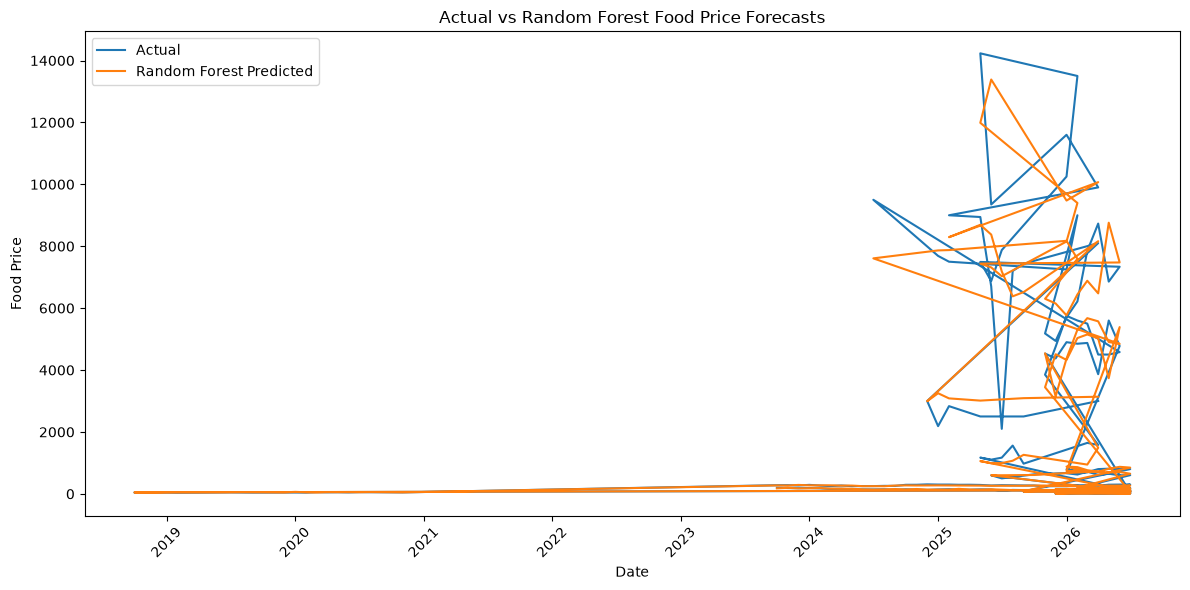

In [139]:
plt.figure(figsize=(12, 6))

plt.plot(
    test["date"],
    y_test.values,
    label="Actual"
)

plt.plot(
    test["date"],
    final_rf_test_pred,
    label="Random Forest Predicted"
)

plt.xlabel("Date")
plt.ylabel("Food Price")
plt.title("Actual vs Random Forest Food Price Forecasts")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [140]:
model_dir = Path("../data/models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "food_price_forecast.joblib"

joblib.dump(
    final_rf_pipeline,
    model_path
)

print("Model saved to:", model_path)

Model saved to: ..\data\models\food_price_forecast.joblib


In [141]:
metadata = {
    "model": "RandomForestRegressor",
    "model_version": "1.0",
    "target": target,
    "features": features,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "training_rows": len(train_validation),
    "test_rows": len(test),
    "test_mae": 226.982710,
    "test_rmse": 670.976313,
    "test_r2": 0.941782,
    "test_mape": 11.985635,
    "hyperparameters": {
        "n_estimators": 500,
        "max_depth": 12,
        "min_samples_leaf": 1,
        "random_state": 42
    }
}

metadata_path = model_dir / "food_price_forecast_metadata.json"

with open(metadata_path, "w") as file:
    json.dump(
        metadata,
        file,
        indent=4
    )

print("Metadata saved to:", metadata_path)

Metadata saved to: ..\data\models\food_price_forecast_metadata.json


In [142]:
loaded_model = joblib.load(
    "../data/models/food_price_forecast.joblib"
)

loaded_prediction = loaded_model.predict(
    X_test.iloc[:5]
)

loaded_prediction

array([179.35137137, 193.0978492 , 179.87762853, 181.55839014,
       188.68704456])

# INFLATION

In [143]:
df = pd.read_csv("../data/processed/macro_inflation_forecast.csv")

In [144]:
df.head()

,date,inflation_12m,inflation_lag_1,inflation_lag_3,inflation_lag_6,inflation_lag_12,cbr,tbill_91,tbill_182,interbank,lending,deposit,savings,target_inflation_next_month
0,2006-06-01,4.28,4.47,8.85,4.70,11.92,9.75,6.60,7.32,6.41,13.79,4.35,1.27,4.16
1,2006-07-01,4.16,4.28,5.44,8.39,11.76,9.75,5.89,6.42,5.74,13.72,4.31,1.32,4.92
2,2006-08-01,4.92,4.16,4.47,9.39,6.87,10.00,5.96,6.47,5.66,13.64,4.08,1.41,5.93
3,2006-09-01,5.93,4.92,4.28,8.85,4.27,10.00,6.45,7.45,6.02,13.54,4.04,1.36,6.55
4,2006-10-01,6.55,5.93,4.16,5.44,3.72,10.00,6.83,8.31,6.08,14.01,4.11,1.35,6.64


In [145]:
print(df.shape)
print(df.columns)
df.info()

(241, 14)
Index(['date', 'inflation_12m', 'inflation_lag_1', 'inflation_lag_3',
       'inflation_lag_6', 'inflation_lag_12', 'cbr', 'tbill_91', 'tbill_182',
       'interbank', 'lending', 'deposit', 'savings',
       'target_inflation_next_month'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   date                         241 non-null    object 
 1   inflation_12m                241 non-null    float64
 2   inflation_lag_1              241 non-null    float64
 3   inflation_lag_3              241 non-null    float64
 4   inflation_lag_6              241 non-null    float64
 5   inflation_lag_12             241 non-null    float64
 6   cbr                          241 non-null    float64
 7   tbill_91                     241 non-null    float64
 8   tbill_182                    241 non-n

In [146]:
#understanding target variable
df['target_inflation_next_month'].describe()

count    241.000000
mean       7.091909
std        3.798854
min        1.850000
25%        4.590000
50%        6.090000
75%        7.740000
max       19.720000
Name: target_inflation_next_month, dtype: float64

<Axes: xlabel='target_inflation_next_month', ylabel='Count'>

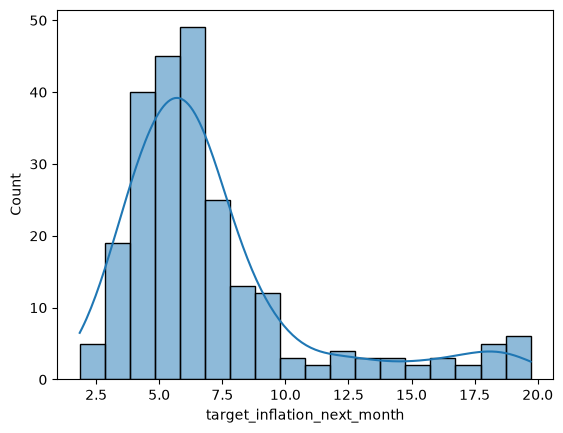

In [147]:
sns.histplot(df['target_inflation_next_month'], kde=True)

In [148]:
#checking null values
df.isna().sum()

date                           0
inflation_12m                  0
inflation_lag_1                0
inflation_lag_3                0
inflation_lag_6                0
inflation_lag_12               0
cbr                            0
tbill_91                       0
tbill_182                      0
interbank                      0
lending                        0
deposit                        0
savings                        0
target_inflation_next_month    0
dtype: int64

In [149]:
df['date'] = pd.to_datetime(df['date'])

In [150]:
df.corr()

,date,inflation_12m,inflation_lag_1,inflation_lag_3,inflation_lag_6,inflation_lag_12,cbr,tbill_91,tbill_182,interbank,lending,deposit,savings,target_inflation_next_month
date,1.000000,-0.332423,-0.325911,-0.322449,-0.309398,-0.278192,0.047788,0.276649,0.251811,0.123132,-0.187062,0.751374,0.584328,-0.339247
inflation_12m,-0.332423,1.000000,0.963144,0.821630,0.513815,-0.163978,0.194696,0.280668,0.260758,0.323725,0.133852,-0.251811,-0.246299,0.963075
inflation_lag_1,-0.325911,0.963144,1.000000,0.897506,0.617514,-0.059565,0.275168,0.332436,0.319242,0.356324,0.192050,-0.191028,-0.235308,0.900115
inflation_lag_3,-0.322449,0.821630,0.897506,1.000000,0.816103,0.173554,0.396499,0.374033,0.369803,0.370589,0.290626,-0.086874,-0.211230,0.727601
inflation_lag_6,-0.309398,0.513815,0.617514,0.816103,1.000000,0.503812,0.461296,0.325398,0.331436,0.291555,0.396981,0.022674,-0.186804,0.404844
inflation_lag_12,-0.278192,-0.163978,-0.059565,0.173554,0.503812,1.000000,0.189962,0.059780,0.067282,-0.028677,0.353298,0.042342,-0.144888,-0.230634
cbr,0.047788,0.194696,0.275168,0.396499,0.461296,0.189962,1.000000,0.747536,0.774263,0.761101,0.681699,0.546134,0.054860,0.105795
tbill_91,0.276649,0.280668,0.332436,0.374033,0.325398,0.059780,0.747536,1.000000,0.973038,0.810948,0.515547,0.649208,0.076028,0.220761
tbill_182,0.251811,0.260758,0.319242,0.369803,0.331436,0.067282,0.774263,0.973038,1.000000,0.763978,0.513750,0.672279,0.151232,0.194586
interbank,0.123132,0.323725,0.356324,0.370589,0.291555,-0.028677,0.761101,0.810948,0.763978,1.000000,0.586172,0.444315,-0.097565,0.269664


## Modeling

### 1. Naive Baseline

In [151]:
df = df.sort_values("date").reset_index(drop=True)

In [152]:
#chronological train test split
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index].copy()
test = df.iloc[split_index:].copy()

In [153]:
y_test = test["target_inflation_next_month"]

naive_pred = test["inflation_12m"]

In [154]:
#evaluation
mae = mean_absolute_error(y_test,naive_pred)
rmse = np.sqrt(mean_squared_error(y_test,naive_pred))

print(f"Naive Baseline MAE: {mae:.4f}")
print(f"Naive Baseline RMSE: {rmse:.4f}")

Naive Baseline MAE: 0.3759
Naive Baseline RMSE: 0.5450


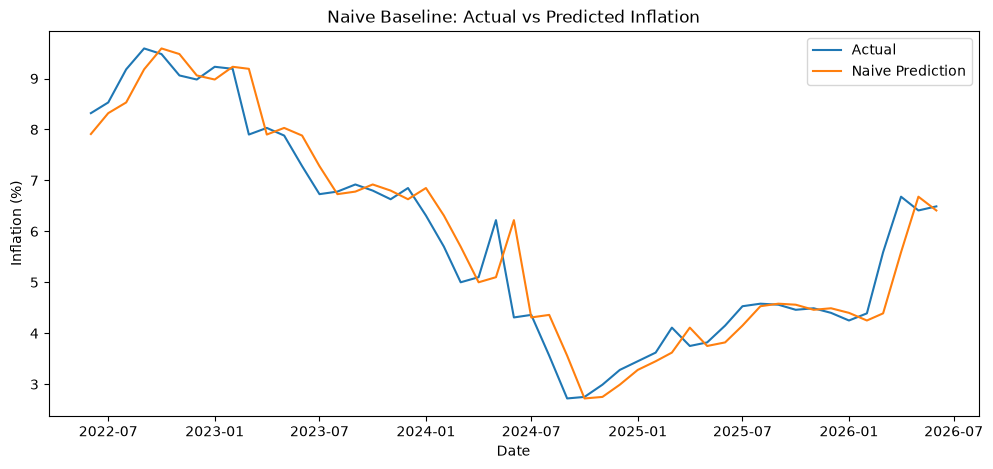

In [155]:
#actual vs predicted
plt.figure(figsize=(12, 5))

plt.plot(test["date"], y_test, label="Actual")
plt.plot(test["date"], naive_pred, label="Naive Prediction")

plt.title("Naive Baseline: Actual vs Predicted Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.legend()
plt.show()

### 2. SARIMAX

In [156]:
y_train = train["target_inflation_next_month"]
y_test = test["target_inflation_next_month"]

features = [
    "cbr", "tbill_91", "tbill_182",
    "interbank", "lending", "deposit", "savings"
]

X_train = train[features]
X_test = test[features]

In [157]:
#fit the model
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 0, 1)
)

sarimax_model = model.fit(disp=False)

In [158]:
#prediction on test period
sarimax_pred = sarimax_model.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test
)

In [159]:
#evaluation
sarimax_mae = mean_absolute_error(y_test, sarimax_pred)
sarimax_rmse = np.sqrt(mean_squared_error(y_test, sarimax_pred))

print(f"SARIMAX MAE: {sarimax_mae:.4f}")
print(f"SARIMAX RMSE: {sarimax_rmse:.4f}")

SARIMAX MAE: 2.0093
SARIMAX RMSE: 2.4678


### 3. XGBoost

In [160]:
#train test split
features = [
    "inflation_12m",
    "inflation_lag_1",
    "inflation_lag_3",
    "inflation_lag_6",
    "inflation_lag_12",
    "cbr",
    "tbill_91",
    "tbill_182",
    "interbank",
    "lending",
    "deposit",
    "savings"
]

X_train = train[features]
X_test = test[features]

y_train = train["target_inflation_next_month"]
y_test = test["target_inflation_next_month"]

In [161]:
#train model
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [162]:
#prediction
xgb_pred = xgb_model.predict(X_test)

In [163]:
#evaluation
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"XGBoost MAE: {xgb_mae:.4f}")
print(f"XGBoost RMSE: {xgb_rmse:.4f}")

XGBoost MAE: 0.6410
XGBoost RMSE: 0.8109


In [164]:
#comparing the 3 models
results = pd.DataFrame({
    "Model": ["Naive Baseline", "SARIMAX", "XGBoost"],
    "MAE": [mae, sarimax_mae, xgb_mae],
    "RMSE": [rmse, sarimax_rmse, xgb_rmse]
})

results

,Model,MAE,RMSE
0,Naive Baseline,0.375918,0.545026
1,SARIMAX,2.009321,2.467841
2,XGBoost,0.640963,0.810883


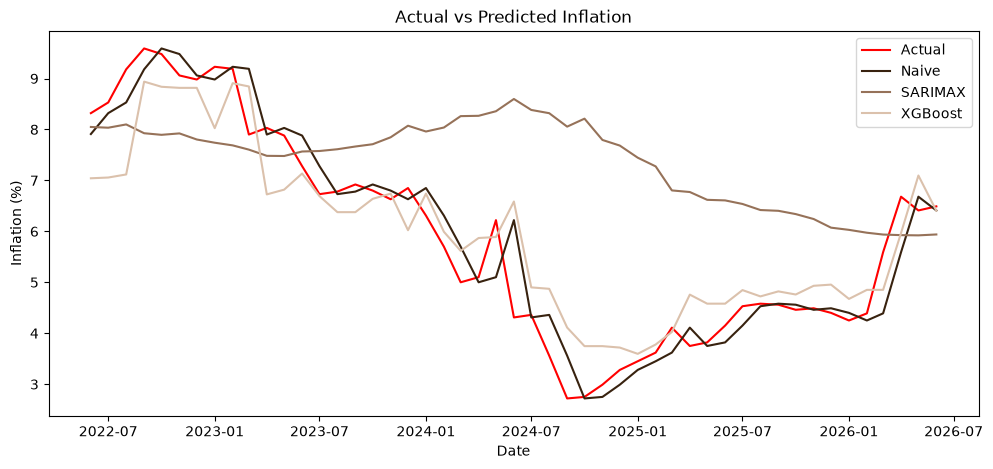

In [165]:
#actual vs predicted of all 3 models
plt.figure(figsize=(12, 5))

plt.plot(test["date"], y_test, label="Actual", c = 'r')
plt.plot(test["date"], naive_pred, label="Naive", c ="#38220f")
plt.plot(test["date"], sarimax_pred, label="SARIMAX", c='#967259')
plt.plot(test["date"], xgb_pred, label="XGBoost", c='#dbc1ac')

plt.title("Actual vs Predicted Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.legend()
plt.show()

In [166]:
# save the models

# Create model directory
model_dir = Path("../data/models")
model_dir.mkdir(parents=True, exist_ok=True)

# Define separate paths
xgb_path = model_dir / "xgb_model.pkl"
sarimax_path = model_dir / "sarimax_model.pkl"

# Save XGBoost model
joblib.dump(xgb_model, xgb_path)

# Save SARIMAX model
joblib.dump(sarimax_model, sarimax_path)

print("XGBoost model saved to:", xgb_path)
print("SARIMAX model saved to:", sarimax_path)

XGBoost model saved to: ..\data\models\xgb_model.pkl
SARIMAX model saved to: ..\data\models\sarimax_model.pkl
